In [59]:
import numpy   as np
import pandas  as pd
import seaborn as sns

import plotly.express as px
import matplotlib.pyplot as plt

In [60]:
import umap
import igraph as ig
import leidenalg

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors     import kneighbors_graph
from sklearn.metrics       import silhouette_score

In [62]:
df = pd.read_csv("../data/processed/SDSS_DR16Q_phot_cleaned.csv")
print(df.describe())

               M_u          M_g          M_r          M_i          M_z  \
count  5935.000000  5935.000000  5935.000000  5935.000000  5935.000000   
mean    -23.914679   -24.192810   -24.574528   -24.724518   -24.940682   
std       1.151138     1.096100     1.098611     1.114149     1.153328   
min     -27.231554   -27.238091   -27.768663   -27.962621   -28.140199   
25%     -24.733397   -24.969967   -25.351485   -25.519093   -25.765793   
50%     -24.134018   -24.401495   -24.791762   -24.958248   -25.181390   
75%     -23.243881   -23.540945   -23.897006   -24.008549   -24.201267   
max     -13.022707   -13.312716   -13.485963   -13.780519   -13.866339   

             M_FUV        M_NUV         M_2j         M_2h         M_2k  \
count  5935.000000  5935.000000  5935.000000  5935.000000  5935.000000   
mean    -21.604725   -22.959326   -25.199575   -25.484911   -25.811102   
std       2.073087     1.704279     1.223701     1.204078     1.119651   
min     -26.006954   -26.724748   -28

In [63]:
df_features = pd.DataFrame(index=df.index)
# df_features = df["SDSS_NAME"]

# Colores Ópticos y UV (Pendiente del disco de acreción)
df_features['u_g'] = df['M_u'] - df['M_g']
df_features['g_r'] = df['M_g'] - df['M_r']
df_features['r_i'] = df['M_r'] - df['M_i']
df_features['i_z'] = df['M_i'] - df['M_z']
df_features['FUV_NUV'] = df['M_FUV'] - df['M_NUV']

# Colores Infrarrojos (Emisión térmica del polvo/toroide)
df_features['j_h'] = df['M_2j'] - df['M_2h']
df_features['h_k'] = df['M_2h'] - df['M_2k']
df_features['W1_W2'] = df['M_W1'] - df['M_W2']

# Cruces espectrales (Relación óptica-infrarroja)
df_features['opt_mir'] = df['M_i'] - df['M_W1']

In [64]:
print(df_features.describe())

               u_g          g_r          r_i          i_z      FUV_NUV  \
count  5935.000000  5935.000000  5935.000000  5935.000000  5935.000000   
mean      0.278131     0.381719     0.149989     0.216164     1.354601   
std       0.366744     0.166886     0.120777     0.114913     1.724172   
min      -4.870668    -1.162133    -3.743732    -0.469820    -5.853674   
25%       0.136099     0.289487     0.088703     0.158806     0.204845   
50%       0.212168     0.356248     0.143080     0.223732     0.889205   
75%       0.324038     0.438951     0.201168     0.281119     1.917681   
max       7.027438     5.479307     0.974532     1.710193    12.451260   

               j_h          h_k        W1_W2      opt_mir  
count  5935.000000  5935.000000  5935.000000  5935.000000  
mean      0.285336     0.326190     0.785876     1.509696  
std       0.301960     0.327490     0.182171     0.420807  
min      -1.465746    -1.632679    -0.338321    -0.470124  
25%       0.108079     0.133438  

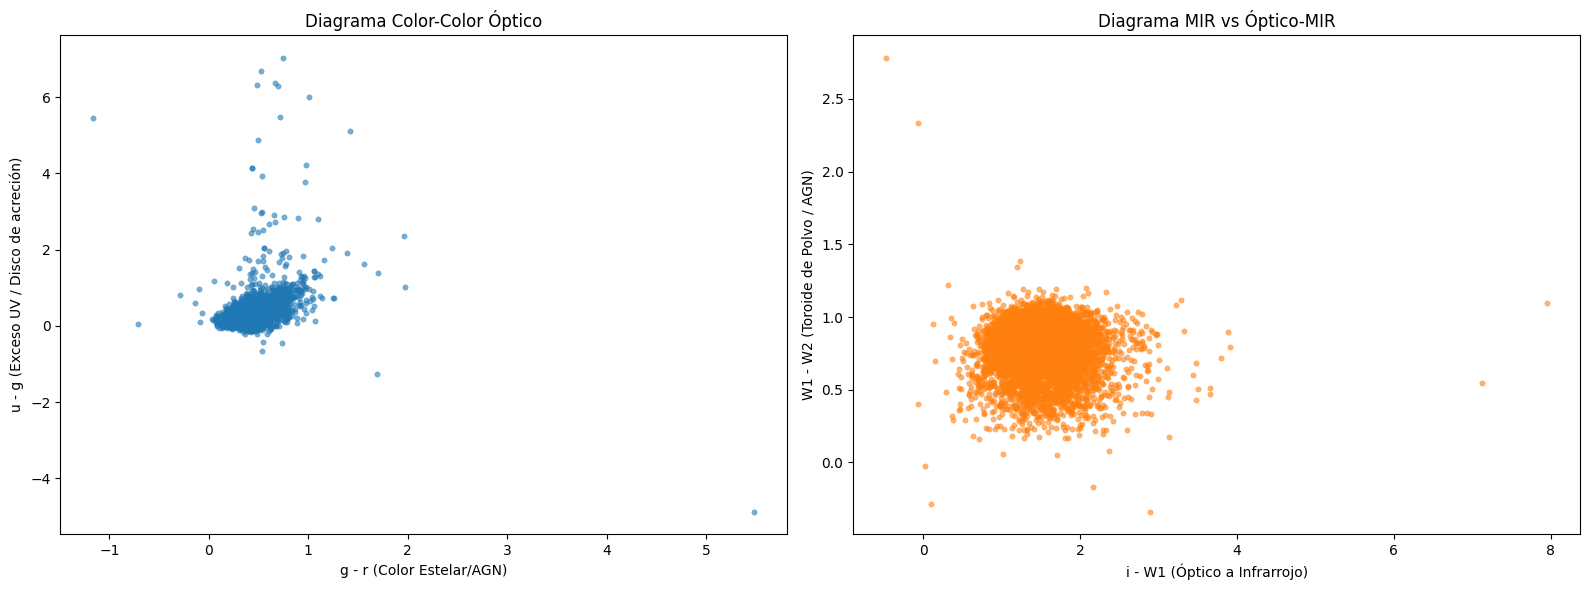

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# a) Diagrama Óptico (u-g vs g-r)
sns.scatterplot(
    data=df_features, 
    x='g_r', y='u_g', 
    alpha=0.6, s=15, edgecolor=None, color='#1f77b4',
    ax=axes[0]
)
axes[0].set_title('Diagrama Color-Color Óptico')
axes[0].set_xlabel('g - r (Color Estelar/AGN)')
axes[0].set_ylabel('u - g (Exceso UV / Disco de acreción)')

# Opcional: Invertir ejes si es convención en tu análisis (los colores más azules a veces van abajo/izquierda)
# b) Diagrama Infrarrojo Medio vs Óptico-MIR (W1-W2 vs opt-mir)
sns.scatterplot(
    data=df_features, 
    x='opt_mir', y='W1_W2', 
    alpha=0.6, s=15, edgecolor=None, color='#ff7f0e',
    ax=axes[1]
)
axes[1].set_title('Diagrama MIR vs Óptico-MIR')
axes[1].set_xlabel('i - W1 (Óptico a Infrarrojo)')
axes[1].set_ylabel('W1 - W2 (Toroide de Polvo / AGN)')
plt.tight_layout()
plt.show()

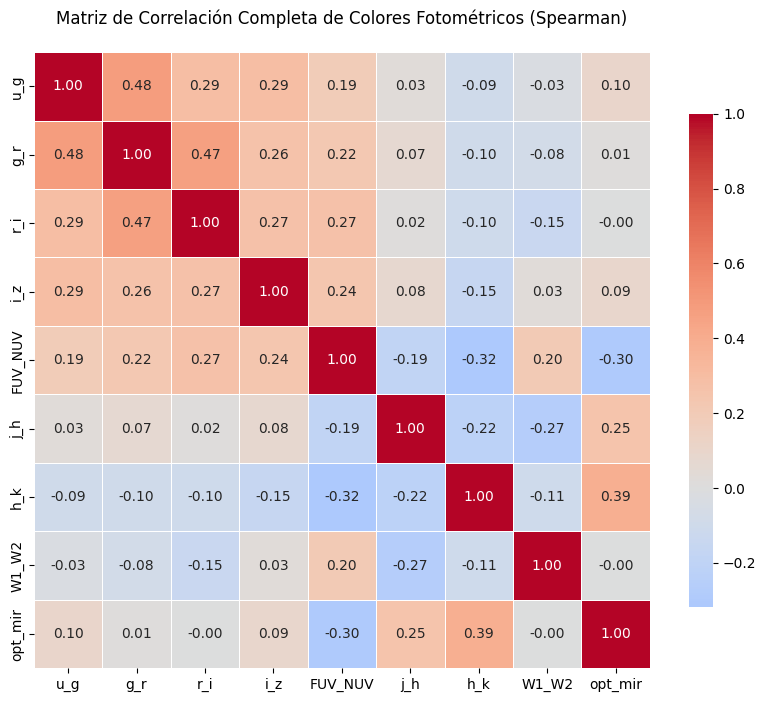

In [66]:
plt.figure(figsize=(10, 8))

# Calculamos la matriz de correlación (Spearman)
corr_matrix = df_features.corr(method='spearman')

# Mapa de calor COMPLETO (sin usar 'mask')
sns.heatmap(
    corr_matrix, 
    cmap='coolwarm', 
    center=0, 
    annot=True,     # Muestra los valores numéricos
    fmt=".2f",      # Formato a 2 decimales
    square=True,    # Hace que las celdas sean cuadradas perfectas
    linewidths=.5,  # Líneas de separación
    cbar_kws={"shrink": .8} # Tamaño de la barra de color
)

plt.title('Matriz de Correlación Completa de Colores Fotométricos (Spearman)', pad=20)
plt.show()


In [67]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

In [73]:
reducer = umap.UMAP(
    n_components=3, 
    n_neighbors=35,       # Balance entre estructura local y global
    metric='manhattan',   # Ideal para acotar el crecimiento del error
)
X_umap = reducer.fit_transform(X_scaled)

In [74]:
k_vecinos = 35

# 1. Obtenemos el grafo de distancias (k-NN)
A_dist = kneighbors_graph(X_umap, n_neighbors=20, mode='distance', metric='manhattan')

# 2. Calculamos el ancho de banda (sigma) empírico
# Usamos la distancia media de todos los enlaces como factor de escala para suavizar
sigma = np.mean(A_dist.data) 

# 3. Aplicamos el Heat Kernel (Kernel Gaussiano) a las distancias que NO son cero
A_dist.data = np.exp(- (A_dist.data**2) / (sigma**2))

# 4. Construimos el grafo de igraph
sources, targets = A_dist.nonzero()
weights = A_dist.data
grafo = ig.Graph(edges=list(zip(sources, targets)), directed=False)
grafo.es['weight'] = weights

In [75]:
partition = leidenalg.find_partition(
    grafo, 
    leidenalg.RBConfigurationVertexPartition, 
    weights=weights,
    resolution_parameter=0.1  # Modifica este valor entre 0.1 y 1.0 para afinar
)

labels = partition.membership
df['community'] = labels

In [76]:
sil_score = silhouette_score(X_umap, labels, metric='manhattan')

print(f"Total de comunidades detectadas: {max(labels) + 1}")
print(f"Silhouette Score: {sil_score:.3f}")

Total de comunidades detectadas: 6
Silhouette Score: 0.375


In [77]:
df_plot = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_plot['community'] = labels

# Convertimos a string para que Plotly y Seaborn lo traten como categoría, no como un continuo
df_plot['community'] = df_plot['community'].astype(str)

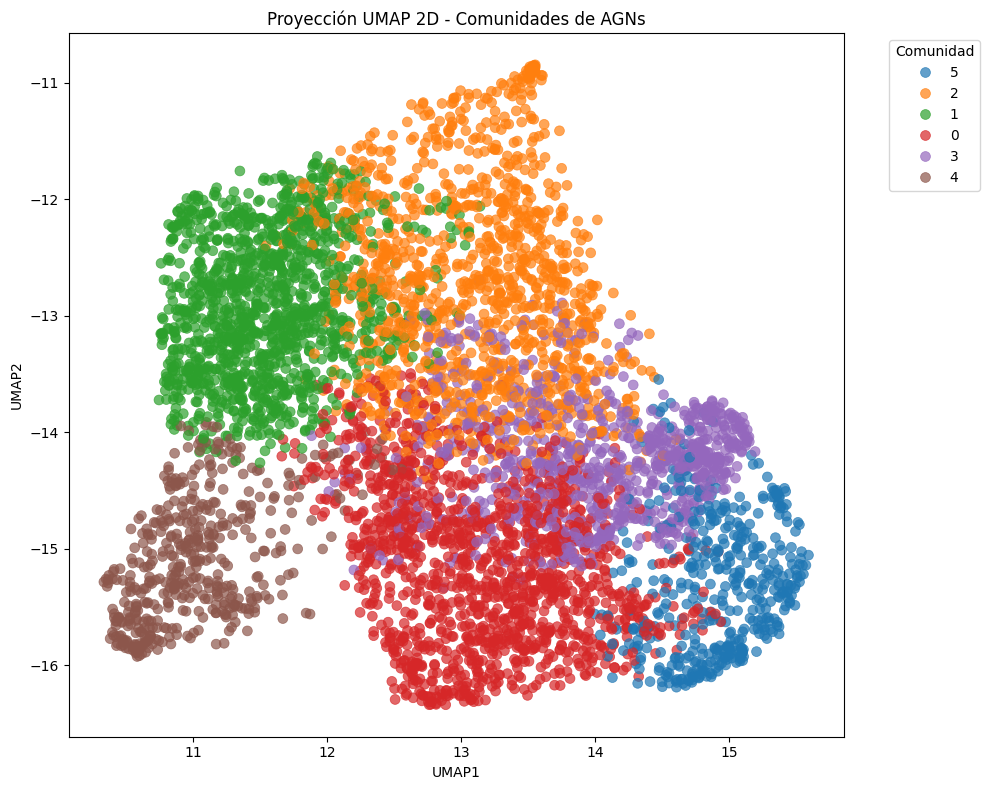

In [78]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='UMAP1', y='UMAP2', 
    hue='community', 
    palette='tab10', # Paleta categórica
    data=df_plot, 
    s=50, alpha=0.7, edgecolor=None
)
plt.title('Proyección UMAP 2D - Comunidades de AGNs')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Comunidad')
plt.tight_layout()
plt.show()

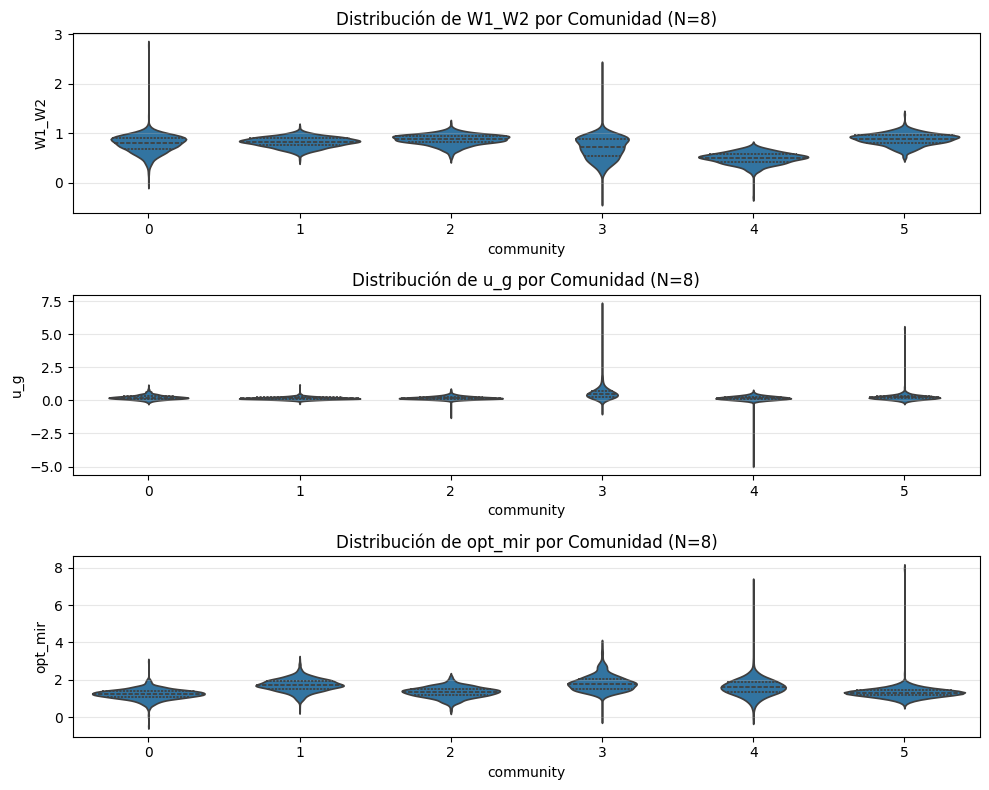

In [79]:
# 1. Unimos las features calculadas con el DataFrame original que tiene las etiquetas de comunidad
# Esto asegura que 'W1_W2', 'u_g', etc., estén disponibles para Seaborn
df_full = pd.concat([df, df_features], axis=1)

# 2. Definimos las variables para el análisis de estadios físicos [cite: 154]
features_to_plot = ['W1_W2', 'u_g', 'opt_mir']

plt.figure(figsize=(10, 8))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(3, 1, i)
    
    # El Violin Plot permite visualizar la densidad paramétrica conectiva de los subgrafos [cite: 123]
    sns.violinplot(
        x='community', 
        y=feature, 
        data=df_full, 
        inner='quartile' 
    )
    
    plt.title(f'Distribución de {feature} por Comunidad (N=8)')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [80]:
comunidades = [0, 1, 2, 3, 4, 5]

for i in comunidades:
    df_temp = df_full[df_full['community'] == i]
    
    filename = f'../data/communities/df_community_{i}.csv'
    df_temp.to_csv(filename, index=False)